# Sentiment Analysis Project (Colab-Friendly Version)

This notebook is a lighter version of the full project notebook, designed to run more reliably in Google Colab while still covering the assignment requirements:

1. Data collection and preprocessing  
2. Model development for BiLSTM and DistilBERT  
3. Hyperparameter tuning  
4. Evaluation with accuracy, precision, recall, F1, and confusion matrices  
5. Interpretability and analysis  
6. Visualization and reporting  

**Runtime note:** this version uses smaller sample sizes and fewer tuning combinations to reduce crashes and training time in Colab.

## 1. Setup
Install required packages if needed.

In [1]:
!pip -q install transformers datasets lime shap scikit-learn seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset
from lime.lime_text import LimeTextExplainer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)



## 2. Load Dataset

Upload `yelp_reviews.csv` to Colab or place it in the working directory.
Expected columns:
- `text`
- `sentiment`

In [4]:
df = pd.read_csv("yelp_reviews.csv", usecols=["text", "sentiment"], nrows=10000 )
df = df[["text", "sentiment"]].dropna()
print(df.head())

                                                text sentiment
0  If you decide to eat here, just be aware it is...   neutral
1  I've taken a lot of spin classes over the year...  positive
2  Family diner. Had the buffet. Eclectic assortm...   neutral
3  Wow!  Yummy, different,  delicious.   Our favo...  positive
4  Cute interior and owner (?) gave us tour of up...  positive


## 3. Preprocessing
Clean text for the BiLSTM model and prepare labels.

In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)
print(df[["sentiment", "label"]].drop_duplicates().sort_values("label"))

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
  sentiment  label
5  negative      0
0   neutral      1
1  positive      2


In [6]:
MAX_SAMPLES = min(12000, len(df))
df_small = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), max(1, round(MAX_SAMPLES * len(x) / len(df)))), random_state=SEED))
      .sample(frac=1, random_state=SEED)
      .reset_index(drop=True)
)


if len(df_small) > MAX_SAMPLES:
    df_small = (
        df_small.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(frac=1, random_state=SEED))
        .reset_index(drop=True)
        .iloc[:MAX_SAMPLES]
    )

print("Sampled rows:", len(df_small))
print(df_small["label"].value_counts(normalize=True).sort_index())

Sampled rows: 10000
label
0    0.1842
1    0.1139
2    0.7019
Name: proportion, dtype: float64


/tmp/ipykernel_1116/1372160402.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), max(1, round(MAX_SAMPLES * len(x) / len(df)))), random_state=SEED))


## 5. Train / Validation / Test Split
Stratified split to preserve class balance.

In [7]:
train_df, temp_df = train_test_split(
    df_small,
    test_size=0.30,
    random_state=SEED,
    stratify=df_small["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=True).sort_index())
print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=True).sort_index())
print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=True).sort_index())

Train: (7000, 4)
Validation: (1500, 4)
Test: (1500, 4)

Train label distribution:
label
0    0.184286
1    0.113857
2    0.701857
Name: proportion, dtype: float64

Validation label distribution:
label
0    0.184
1    0.114
2    0.702
Name: proportion, dtype: float64

Test label distribution:
label
0    0.184
1    0.114
2    0.702
Name: proportion, dtype: float64


## 6. Review Length Analysis
Used later for short vs. long review analysis.

In [8]:
for split_df in [train_df, val_df, test_df]:
    split_df["review_len_words"] = split_df["clean_text"].apply(lambda x: len(x.split()))

length_threshold = train_df["review_len_words"].median()
print("Median review length:", length_threshold)

Median review length: 73.0


## 7. BiLSTM Baseline Preparation

In [9]:
VOCAB_SIZE = 5000
MAX_LEN = 120

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

def to_padded(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_train = to_padded(train_df["clean_text"])
X_val = to_padded(val_df["clean_text"])
X_test = to_padded(test_df["clean_text"])

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print(X_train.shape, X_val.shape, X_test.shape)

(7000, 120) (1500, 120) (1500, 120)


## 8. BiLSTM Hyperparameter Tuning
A lightweight tuning loop for Colab.

In [10]:
bilstm_trials = [
    {"embed_dim": 32, "units": 32, "dropout": 0.2, "batch_size": 32},
    {"embed_dim": 64, "units": 32, "dropout": 0.3, "batch_size": 32},
]

bilstm_results = []

for i, cfg in enumerate(bilstm_trials, start=1):
    tf.keras.backend.clear_session()

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=cfg["embed_dim"]),
        Bidirectional(LSTM(cfg["units"])),
        Dropout(cfg["dropout"]),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early = EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=3,
        batch_size=cfg["batch_size"],
        verbose=1,
        callbacks=[early]
    )

    val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc = accuracy_score(y_val, val_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="macro", zero_division=0)

    bilstm_results.append({
        **cfg,
        "val_accuracy": acc,
        "val_macro_precision": p,
        "val_macro_recall": r,
        "val_macro_f1": f1
    })

bilstm_results_df = pd.DataFrame(bilstm_results).sort_values("val_macro_f1", ascending=False)
bilstm_results_df

Epoch 1/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7109 - loss: 0.7445 - val_accuracy: 0.7693 - val_loss: 0.6089
Epoch 2/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8141 - loss: 0.4937 - val_accuracy: 0.8027 - val_loss: 0.5179
Epoch 3/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8493 - loss: 0.3916 - val_accuracy: 0.8147 - val_loss: 0.5086
Epoch 1/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7241 - loss: 0.7194 - val_accuracy: 0.7960 - val_loss: 0.5528
Epoch 2/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8233 - loss: 0.4725 - val_accuracy: 0.8127 - val_loss: 0.5219
Epoch 3/3
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8551 - loss: 0.3737 - val_accuracy: 0.8167 - val_loss: 0.5036


,embed_dim,units,dropout,batch_size,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1
1,64,32,0.3,32,0.816667,0.637875,0.610705,0.597490
0,32,32,0.2,32,0.814667,0.831003,0.596999,0.543311


## 9. Train Final BiLSTM Model

In [11]:
best_bilstm = bilstm_results_df.iloc[0].to_dict()
best_bilstm

{'embed_dim': 64.0,
 'units': 32.0,
 'dropout': 0.3,
 'batch_size': 32.0,
 'val_accuracy': 0.8166666666666667,
 'val_macro_precision': 0.6378748368757101,
 'val_macro_recall': 0.6107049127008445,
 'val_macro_f1': 0.5974903645899029}

In [ ]:
tf.keras.backend.clear_session()

final_bilstm = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=int(best_bilstm["embed_dim"])),
    Bidirectional(LSTM(int(best_bilstm["units"]))),
    Dropout(float(best_bilstm["dropout"])),
    Dense(3, activation="softmax")
])

final_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
class_weights = {
    0: 1.0,   # keep baseline
    1: 2.0,   # moderately boost minority class
    2: 0.8    # slightly reduce dominant class
}
early = EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True)

history_bilstm = final_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=4,
    batch_size=int(best_bilstm["batch_size"]),
    verbose=1,
    callbacks=[early],
    class_weight=class_weights
)

Epoch 1/4
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.7007 - loss: 0.8808 - val_accuracy: 0.6947 - val_loss: 0.7726
Epoch 2/4
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7803 - loss: 0.6661 - val_accuracy: 0.7540 - val_loss: 0.6105
Epoch 3/4
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8323 - loss: 0.5107 - val_accuracy: 0.7513 - val_loss: 0.5844
Epoch 4/4
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8674 - loss: 0.4100 - val_accuracy: 0.7447 - val_loss: 0.5952


## 10. BiLSTM Evaluation

In [15]:
bilstm_test_probs = final_bilstm.predict(X_test, verbose=0)
bilstm_test_pred = np.argmax(bilstm_test_probs, axis=1)

print(classification_report(y_test, bilstm_test_pred, digits=4, zero_division=0))
cm_bilstm = confusion_matrix(y_test, bilstm_test_pred)
cm_bilstm

              precision    recall  f1-score   support

           0     0.6611    0.7138    0.6864       276
           1     0.2389    0.4386    0.3093       171
           2     0.9302    0.7844    0.8511      1053

    accuracy                         0.7320      1500
   macro avg     0.6100    0.6456    0.6156      1500
weighted avg     0.8019    0.7320    0.7590      1500



array([[197,  61,  18],
       [ 52,  75,  44],
       [ 49, 178, 826]])

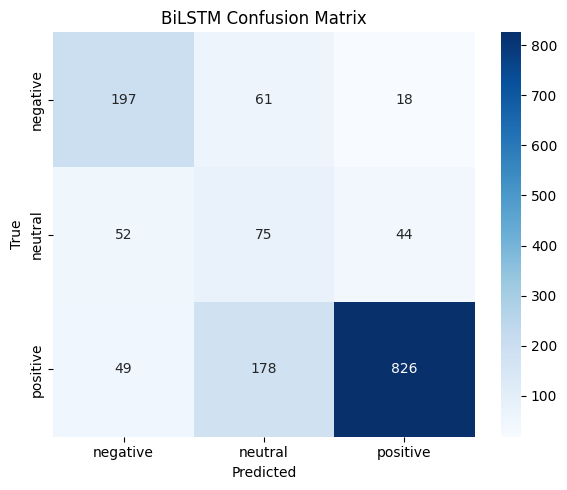

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_bilstm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BiLSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

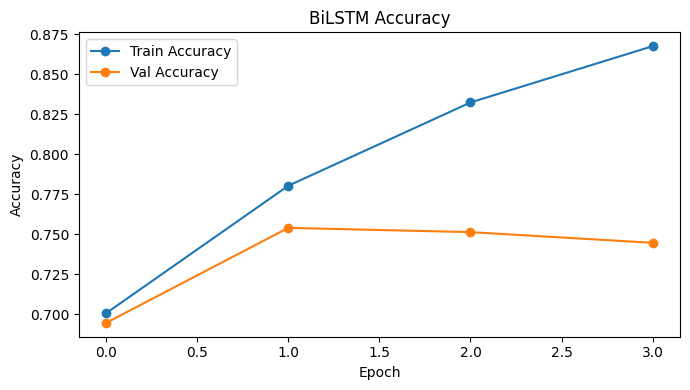

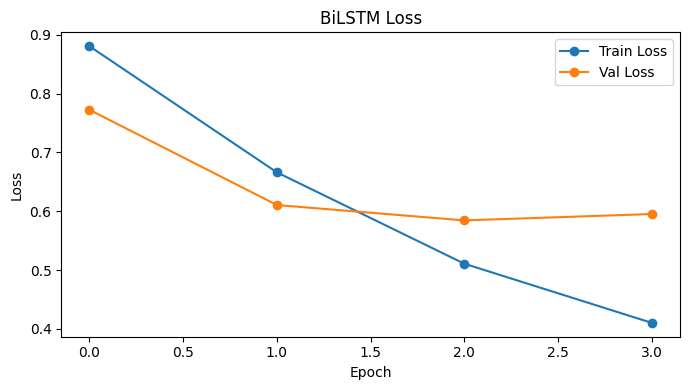

In [17]:
plt.figure(figsize=(7,4))
plt.plot(history_bilstm.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_bilstm.history["val_accuracy"], marker="o", label="Val Accuracy")
plt.title("BiLSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history_bilstm.history["loss"], marker="o", label="Train Loss")
plt.plot(history_bilstm.history["val_loss"], marker="o", label="Val Loss")
plt.title("BiLSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 11. DistilBERT Preparation
Use a smaller sample for transformer fine-tuning if Colab runtime is limited.

In [18]:
BERT_TRAIN_MAX = min(6000, len(train_df))
BERT_VAL_MAX = min(1000, len(val_df))
BERT_TEST_MAX = min(1000, len(test_df))

train_bert = train_df.sample(BERT_TRAIN_MAX, random_state=SEED)
val_bert = val_df.sample(BERT_VAL_MAX, random_state=SEED)
test_bert = test_df.sample(BERT_TEST_MAX, random_state=SEED)

tokenizer_bert = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_batch(batch):
    return tokenizer_bert(batch["text"], truncation=True, padding="max_length", max_length=128)

train_ds = Dataset.from_pandas(train_bert[["text", "label"]], preserve_index=False).map(tokenize_batch, batched=True)
val_ds = Dataset.from_pandas(val_bert[["text", "label"]], preserve_index=False).map(tokenize_batch, batched=True)
test_ds = Dataset.from_pandas(test_bert[["text", "label"]], preserve_index=False).map(tokenize_batch, batched=True)

cols = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=cols)
val_ds.set_format(type="torch", columns=cols)
test_ds.set_format(type="torch", columns=cols)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## 12. DistilBERT Hyperparameter Tuning
Small tuning grid for Colab.

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_precision": p, "macro_recall": r, "macro_f1": f1}

bert_trials = [
    {"learning_rate": 2e-5, "batch_size": 8},
    {"learning_rate": 3e-5, "batch_size": 8},
]

bert_results = []

for i, cfg in enumerate(bert_trials, start=1):
    model_bert = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=3
    )

    args = TrainingArguments(
        output_dir=f"./bert_trial_{i}",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["batch_size"],
        num_train_epochs=1,
        weight_decay=0.01,
        report_to="none"
    )

    trainer = Trainer(
        model=model_bert,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()
    bert_results.append({
        **cfg,
        "val_accuracy": metrics["eval_accuracy"],
        "val_macro_precision": metrics["eval_macro_precision"],
        "val_macro_recall": metrics["eval_macro_recall"],
        "val_macro_f1": metrics["eval_macro_f1"]
    })

bert_results_df = pd.DataFrame(bert_results).sort_values("val_macro_f1", ascending=False)
bert_results_df

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.471135,0.419932,0.850000,0.736997,0.664616,0.665638


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.478333,0.425720,0.844000,0.720695,0.656259,0.658973


,learning_rate,batch_size,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1
0,0.00002,8,0.850,0.736997,0.664616,0.665638
1,0.00003,8,0.844,0.720695,0.656259,0.658973


## 13. Train Final DistilBERT

In [20]:
best_bert = bert_results_df.iloc[0].to_dict()
best_bert

{'learning_rate': 2e-05,
 'batch_size': 8.0,
 'val_accuracy': 0.85,
 'val_macro_precision': 0.7369971134236165,
 'val_macro_recall': 0.6646160284578363,
 'val_macro_f1': 0.665637905643023}

In [21]:
final_distilbert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

final_args = TrainingArguments(
    output_dir="./final_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    learning_rate=float(best_bert["learning_rate"]),
    per_device_train_batch_size=int(best_bert["batch_size"]),
    per_device_eval_batch_size=int(best_bert["batch_size"]),
    num_train_epochs=2,
    weight_decay=0.01,
    report_to="none"
)

final_trainer = Trainer(
    model=final_distilbert,
    args=final_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

train_output = final_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.486473,0.396670,0.844000,0.714240,0.687543,0.697173
2,0.318227,0.417445,0.847000,0.724555,0.696587,0.709107


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


## 14. DistilBERT Evaluation

In [22]:
bert_eval = final_trainer.evaluate(test_ds)
bert_eval

{'eval_loss': 0.45992931723594666,
 'eval_accuracy': 0.838,
 'eval_macro_precision': 0.6835038005812654,
 'eval_macro_recall': 0.6717468880520698,
 'eval_macro_f1': 0.6769969645188606,
 'eval_runtime': 3.6151,
 'eval_samples_per_second': 276.616,
 'eval_steps_per_second': 34.577,
 'epoch': 2.0}

In [23]:
bert_preds_output = final_trainer.predict(test_ds)
bert_preds = np.argmax(bert_preds_output.predictions, axis=1)
bert_true = np.array(test_bert["label"])

print(classification_report(bert_true, bert_preds, digits=4, zero_division=0))
cm_bert = confusion_matrix(bert_true, bert_preds)
cm_bert

              precision    recall  f1-score   support

           0     0.7708    0.7590    0.7649       195
           1     0.3571    0.3097    0.3318       113
           2     0.9225    0.9465    0.9344       692

    accuracy                         0.8380      1000
   macro avg     0.6835    0.6717    0.6770      1000
weighted avg     0.8291    0.8380    0.8332      1000



array([[148,  36,  11],
       [ 34,  35,  44],
       [ 10,  27, 655]])

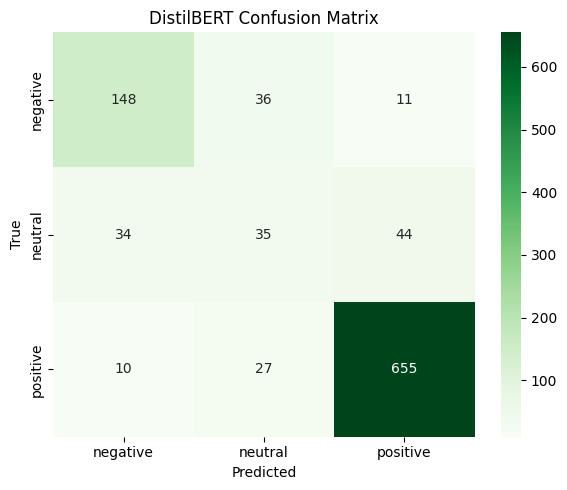

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 15. Results Comparison Table

In [25]:
def metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Accuracy": acc,
        "Macro Precision": p,
        "Macro Recall": r,
        "Macro F1": f1,
        f"{label_encoder.classes_[0]} F1": report["0"]["f1-score"],
        f"{label_encoder.classes_[1]} F1": report["1"]["f1-score"],
        f"{label_encoder.classes_[2]} F1": report["2"]["f1-score"],
    }

bilstm_summary = metrics_from_preds(y_test, bilstm_test_pred)
bert_summary = metrics_from_preds(bert_true, bert_preds)

comparison_df = pd.DataFrame([bilstm_summary, bert_summary], index=["BiLSTM", "DistilBERT"]).T
comparison_df

,BiLSTM,DistilBERT
Accuracy,0.732000,0.838000
Macro Precision,0.610036,0.683504
Macro Recall,0.645597,0.671747
Macro F1,0.615599,0.676997
negative F1,0.686411,0.764858
neutral F1,0.309278,0.331754
positive F1,0.851108,0.934379


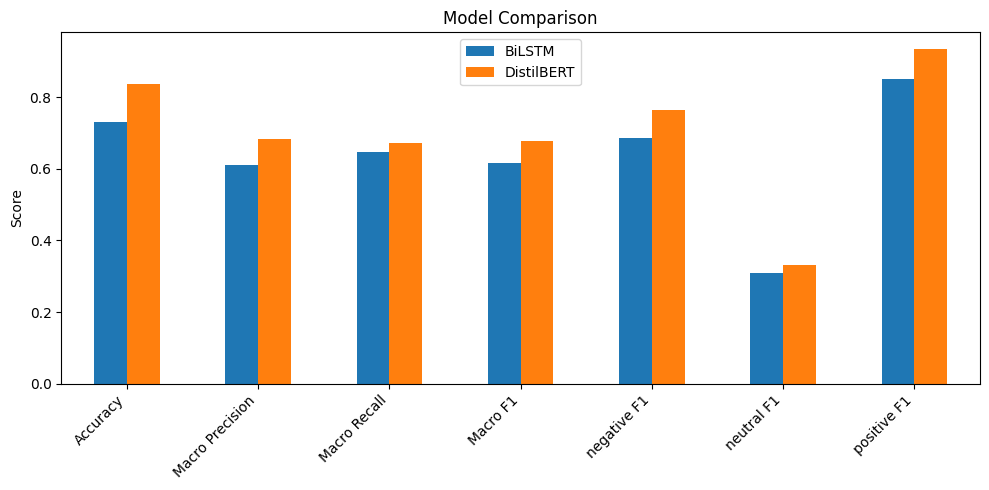

In [26]:
comparison_df.plot(kind="bar", figsize=(10,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Short vs Long Review Analysis
Evaluate each model by review length.

In [27]:
test_len_df = test_df.copy()
test_len_df["pred_bilstm"] = bilstm_test_pred
test_len_df["length_group"] = np.where(test_len_df["review_len_words"] <= length_threshold, "Short", "Long")

def subgroup_report(df_sub, true_col="label", pred_col="pred_bilstm"):
    return {
        "accuracy": accuracy_score(df_sub[true_col], df_sub[pred_col]),
        "macro_f1": precision_recall_fscore_support(df_sub[true_col], df_sub[pred_col], average="macro", zero_division=0)[2]
    }

bilstm_length_results = (
    test_len_df.groupby("length_group")
    .apply(lambda x: pd.Series(subgroup_report(x)))
)
bilstm_length_results

/tmp/ipykernel_1116/1840165296.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series(subgroup_report(x)))


,accuracy,macro_f1
length_group,,
Long,0.694444,0.608481
Short,0.770161,0.619341


In [28]:
test_bert_len = test_bert.copy()
test_bert_len["pred_bert"] = bert_preds
test_bert_len["review_len_words"] = test_bert_len["text"].apply(lambda x: len(str(x).split()))
test_bert_len["length_group"] = np.where(test_bert_len["review_len_words"] <= length_threshold, "Short", "Long")

bert_length_results = (
    test_bert_len.groupby("length_group")
    .apply(lambda x: pd.Series({
        "accuracy": accuracy_score(x["label"], x["pred_bert"]),
        "macro_f1": precision_recall_fscore_support(x["label"], x["pred_bert"], average="macro", zero_division=0)[2]
    }))
)
bert_length_results

/tmp/ipykernel_1116/2901260757.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,accuracy,macro_f1
length_group,,
Long,0.803607,0.661046
Short,0.872255,0.696112


## 17. Vocabulary Analysis
Inspect high-frequency words by sentiment class in the training data.

In [29]:
from collections import Counter

def top_words(texts, n=15):
    counter = Counter()
    for t in texts:
        counter.update(t.split())
    return counter.most_common(n)

for label_id in sorted(train_df["label"].unique()):
    cls_name = label_encoder.inverse_transform([label_id])[0]
    print(f"\nTop words for class {label_id} ({cls_name}):")
    print(top_words(train_df.loc[train_df["label"] == label_id, "clean_text"], n=15))


Top words for class 0 (negative):
[('the', 8472), ('i', 5336), ('and', 5226), ('to', 4626), ('a', 3870), ('was', 3505), ('it', 2479), ('of', 2188), ('for', 1930), ('in', 1791), ('we', 1731), ('my', 1716), ('that', 1711), ('not', 1511), ('t', 1452)]

Top words for class 1 (neutral):
[('the', 5243), ('and', 2864), ('i', 2776), ('a', 2667), ('to', 2135), ('was', 2075), ('it', 1582), ('of', 1454), ('for', 1200), ('is', 1065), ('but', 1040), ('in', 1028), ('that', 921), ('we', 880), ('t', 807)]

Top words for class 2 (positive):
[('the', 23257), ('and', 17220), ('i', 12985), ('a', 12562), ('to', 9843), ('was', 7692), ('it', 6681), ('of', 6547), ('is', 6397), ('for', 5275), ('in', 5250), ('with', 3991), ('my', 3979), ('we', 3860), ('you', 3839)]


## 18. LIME Interpretability for BiLSTM
Runs on one test example to keep Colab runtime manageable.

In [30]:
class_names = list(label_encoder.classes_)

def bilstm_predict_proba(texts):
    arr = to_padded([clean_text(t) for t in texts])
    return final_bilstm.predict(arr, verbose=0)

explainer = LimeTextExplainer(class_names=class_names)

sample_text = test_df.iloc[0]["text"]
sample_true = label_encoder.inverse_transform([test_df.iloc[0]["label"]])[0]
print("Sample true label:", sample_true)
print(sample_text[:500])

exp = explainer.explain_instance(
    sample_text,
    bilstm_predict_proba,
    num_features=10,
    top_labels=1
)

exp.show_in_notebook(text=True)

Sample true label: positive
Great atmosphere. And great burger the Fondu burger was rediculous. The servers aren't bad to look at either.


## 19. DistilBERT Interpretability (Attention-Based)
A lightweight approximation using token importance from attention masks / probabilities.
For full attention visualization, use a specialized notebook or BertViz.

In [ ]:
import torch
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_distilbert.to(device)
final_distilbert.eval()

sample_text_bert = test_bert.iloc[0]["text"]

inputs = tokenizer_bert(
    sample_text_bert,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# move tokenized inputs to same device as model
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = final_distilbert(**inputs, output_attentions=True)


attentions = outputs.attentions[-1].detach().cpu().numpy()
tokens = tokenizer_bert.convert_ids_to_tokens(inputs["input_ids"][0].detach().cpu().tolist())

# Mean attention across heads for [CLS] token to all tokens
cls_attention = attentions[0, :, 0, :].mean(axis=0)

att_df = pd.DataFrame({
    "token": tokens,
    "attention": cls_attention
})

att_df = att_df.sort_values("attention", ascending=False).head(15)
att_df

,token,attention
79,[SEP],0.071469
56,',0.051858
3,!,0.049550
4,what,0.046778
78,.,0.038509
61,.,0.034854
19,.,0.026349
18,incredible,0.025346
6,amazing,0.022796
69,was,0.022503


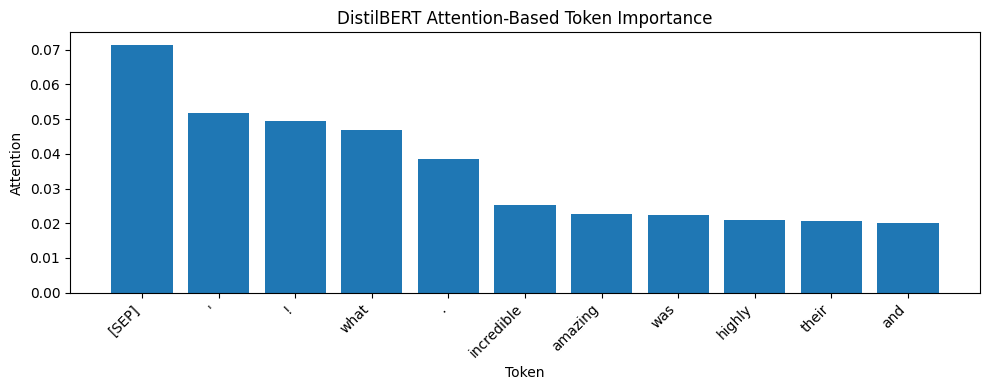

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.bar(att_df["token"], att_df["attention"])
plt.title("DistilBERT Attention-Based Token Importance")
plt.xlabel("Token")
plt.ylabel("Attention")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 20. Final Discussion
Summarize strengths, weaknesses, and findings.

In [37]:
print("BiLSTM best tuning results:")
display(bilstm_results_df)

print("\nDistilBERT best tuning results:")
display(bert_results_df)

print("\nFinal model comparison:")
display(comparison_df)

BiLSTM best tuning results:


,embed_dim,units,dropout,batch_size,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1
1,64,32,0.3,32,0.816667,0.637875,0.610705,0.597490
0,32,32,0.2,32,0.814667,0.831003,0.596999,0.543311



DistilBERT best tuning results:


,learning_rate,batch_size,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1
0,0.00002,8,0.850,0.736997,0.664616,0.665638
1,0.00003,8,0.844,0.720695,0.656259,0.658973



Final model comparison:


,BiLSTM,DistilBERT
Accuracy,0.732000,0.838000
Macro Precision,0.610036,0.683504
Macro Recall,0.645597,0.671747
Macro F1,0.615599,0.676997
negative F1,0.686411,0.764858
neutral F1,0.309278,0.331754
positive F1,0.851108,0.934379
